In [9]:
#Mini project 1: Analysis of solar adoption patterns in New South Wales (NSW)
#Introduction:
#The goal of this project is to understand the historical trends and influencing factors behind rooftop solar PV 
#uptake across NSW postcodes. The ultimate goal is to identify which NSW postcodes are likely to see the highest growth 
#in rooftop solar installations to inform targeted marketing or policy interventions. For this mini project 1(First stage of
#the project), it provides an analysis of solar adoption patterns in NSW. It integrates data from the Clean Energy Regulator (CER) 
#on solar installations and capacity with Australian Bureau of Statistics (ABS) Census data on demographics and dwelling types 
#at the postcode level.
#This mini project contains 4 main stages:
#1.Data Preparation: It loads, cleans, and reshapes raw solar and demographic data, specifically filtering for NSW postcodes.
#2.Metric Calculation: It calculates various normalised metrics, such as solar installations and capacity per person, and per 
#separate house, to understand adoption rates relative to population and housing structure.
#3.Exploratory Data Analysis (EDA): It analyses and visualises monthly solar adoption trends and growth rates across NSW. 
#It also identifies top-performing postcodes based on different solar metrics and examines correlations between solar adoption, 
#median household income, and housing types.
#4.Geographic Visualisation: Finally, it creates an interactive map displaying the geographic distribution of different solar 
#adoption metrics across NSW postcodes, allowing users to explore the data visually with tooltips, pop-ups, and layer controls.


In [10]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas as gpd
import folium    
from folium.features import GeoJsonTooltip, GeoJsonPopup 
import branca.colormap as cm 

In [2]:
# --- Configuration ---
# This section defines essential file paths and geographical ranges needed for the analysis.
data_dir = '/Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/'
# CER Data Files
CAPACITY_FILE = os.path.join(data_dir, 'sgu-solar-capacity-2011-to-present.csv')
INSTALLATIONS_FILE = os.path.join(data_dir, 'sgu-solar-installations-2011-to-present.csv')
# Geographic Data File
poa_file = '/Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/POA_2021_AUST_GDA2020_SHP/POA_2021_AUST_GDA2020.shp'
# ABS Census Data Files
ABS_G02_FILE = '/Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/2021_GCP_POA_for_NSW_short-header/2021 Census GCP Postal Areas for NSW/2021Census_G02_NSW_POA.csv'
ABS_G36_FILE = '/Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/2021_GCP_POA_for_NSW_short-header/2021 Census GCP Postal Areas for NSW/2021Census_G36_NSW_POA.csv'

# NSW postcode ranges 
NSW_POSTCODE_RANGES = [
    (1000, 2599),
    (2620, 2899),
    (2921, 2999)
]

# --- Helper Functions ---
#function to check if a given postcode is within NSW ranges
def is_postcode_in_nsw_ranges(postcode):
    """Checks if a given postcode falls within defined NSW ranges."""
    try:
        postcode = int(postcode)
        for start, end in NSW_POSTCODE_RANGES:
            if start <= postcode <= end:
                return True
        return False
    except (ValueError, TypeError):
        return False

#function to load, reshape, and clean CER data.
def load_and_reshape_cer_data(df_raw: pd.DataFrame, value_column_name: str) -> pd.DataFrame:
    """Loads, reshapes, and cleans raw CER monthly data."""
    print(f"Reshaping and cleaning {value_column_name} data...")

    postcode_col_name = None
    possible_postcode_cols = ['Small Unit Postcode', 'Small Unit Installation Postcode']
    for col in possible_postcode_cols:
        if col in df_raw.columns:
            postcode_col_name = col
            break
    if postcode_col_name is None:
        raise ValueError(f"Could not find a valid postcode column. Expected one of {possible_postcode_cols}.")

    monthly_data_cols = [col for col in df_raw.columns if col != postcode_col_name]
    df_long = df_raw.melt(id_vars=[postcode_col_name], value_vars=monthly_data_cols,
                          var_name='Original_Header', value_name=value_column_name)
    df_long = df_long.rename(columns={postcode_col_name: 'Postcode'})
    
    df_long['Month_Year_Str'] = df_long['Original_Header'].apply(
        lambda x: re.search(r'([A-Za-z]{3} \d{4})', x).group(1) if re.search(r'([A-Za-z]{3} \d{4})', x) else None)
    df_long['Date'] = pd.to_datetime('01 ' + df_long['Month_Year_Str'], format='%d %b %Y', errors='coerce')
    df_long = df_long.drop(columns=['Original_Header', 'Month_Year_Str'])
    df_long = df_long.sort_values(by=['Postcode', 'Date'])
    df_long[value_column_name] = df_long[value_column_name].fillna(0)

    # Convert Postcode to numeric and handle potential issues.
    df_long['Postcode'] = pd.to_numeric(df_long['Postcode'], errors='coerce').fillna(0).astype(int)
    
    df_long = df_long.dropna(subset=['Date'])
    print(f"Finished reshaping and cleaning {value_column_name} data. Total rows: {len(df_long)}")
    return df_long

#function to load and merge ABS demographic data.    
def load_abs_demographics(g02_file_path: str, g36_file_path: str) -> pd.DataFrame:
   
    print(f"Loading ABS demographic data from G02: {g02_file_path} and G36: {g36_file_path}...")
    try:
        # Load G02 data
        df_g02 = pd.read_csv(g02_file_path)
        df_g02_selected = df_g02[['POA_CODE_2021', 'Median_tot_hhd_inc_weekly']].copy()
        df_g02_selected = df_g02_selected.rename(columns={
            'POA_CODE_2021': 'Postcode',
            'Median_tot_hhd_inc_weekly': 'Median_Household_Income_Weekly'
        })
        
        # Load G36 data
        df_g36 = pd.read_csv(g36_file_path)
        df_g36_selected = df_g36[[
            'POA_CODE_2021',
            'Total_PDs_Dwellings', # Total Private Dwellings
            'OPDs_Separate_house_Dwellings', # Occupied Private Dwellings - Separate House
            'OPDs_Flt_apart_Tot_Dwgs', # Occupied Private Dwellings - Flats/Apartments
            'Total_PDs_Persons' # Total Persons in Private Dwellings
        ]].copy()
        df_g36_selected = df_g36_selected.rename(columns={
            'POA_CODE_2021': 'Postcode',
            'Total_PDs_Dwellings': 'Total_Dwellings',
            'OPDs_Separate_house_Dwellings': 'Separate_House_Dwellings',
            'OPDs_Flt_apart_Tot_Dwgs': 'Flat_Apartment_Dwellings',
            'Total_PDs_Persons': 'Total_Persons_in_Dwellings'
        })

        # Merge the two dataframes
        df_abs_merged = pd.merge(df_g02_selected, df_g36_selected, on='Postcode', how='inner')

        # Convert Postcode to integer
        df_abs_merged['Postcode'] = pd.to_numeric(df_abs_merged['Postcode'].str.replace('POA', ''), errors='coerce')
        df_abs_merged = df_abs_merged.dropna(subset=['Postcode'])
        df_abs_merged['Postcode'] = df_abs_merged['Postcode'].astype(int)

        # Convert other demographic columns to numeric, filling NaNs with 0
        numeric_cols = [
            'Median_Household_Income_Weekly',
            'Total_Dwellings',
            'Separate_House_Dwellings',
            'Flat_Apartment_Dwellings',
            'Total_Persons_in_Dwellings'
        ]
        for col in numeric_cols:
            df_abs_merged[col] = pd.to_numeric(df_abs_merged[col], errors='coerce').fillna(0)

        print(f"ABS data merged and cleaned. Head:\n{df_abs_merged.head()}")
        return df_abs_merged

    except FileNotFoundError as e:
        print(f"Error: ABS demographic data file not found. Ensure files are in {os.path.dirname(e.filename)}: {e.filename}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred during ABS data processing: {e}")
        return pd.DataFrame()

--- Starting Solar Adoption Analysis in NSW ---

--- Step 1: Loading Raw CER Data ---
Raw CER Data Loaded Successfully (Step 1).
Loading ABS demographic data from G02: /Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/2021_GCP_POA_for_NSW_short-header/2021 Census GCP Postal Areas for NSW/2021Census_G02_NSW_POA.csv and G36: /Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/2021_GCP_POA_for_NSW_short-header/2021 Census GCP Postal Areas for NSW/2021Census_G36_NSW_POA.csv...
ABS data merged and cleaned. Head:
   Postcode  Median_Household_Income_Weekly  Total_Dwellings  \
0      2000                            2225            15345   
1      2007                            1805             3536   
2      2008                            1746             5516   
3      2009                            2422             6510   
4      2010                            2297            15553   

   Separate_House_Dwellings  Flat_Apartment_Dwellings  \
0                        24                

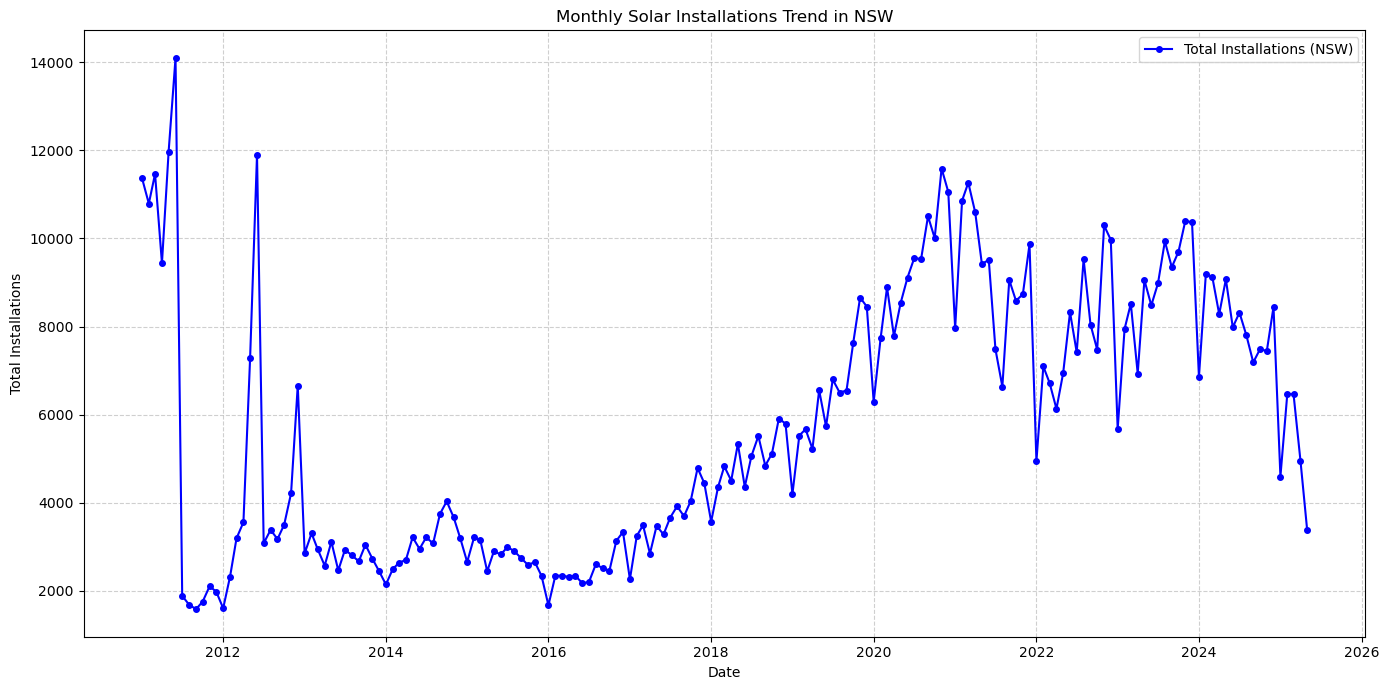

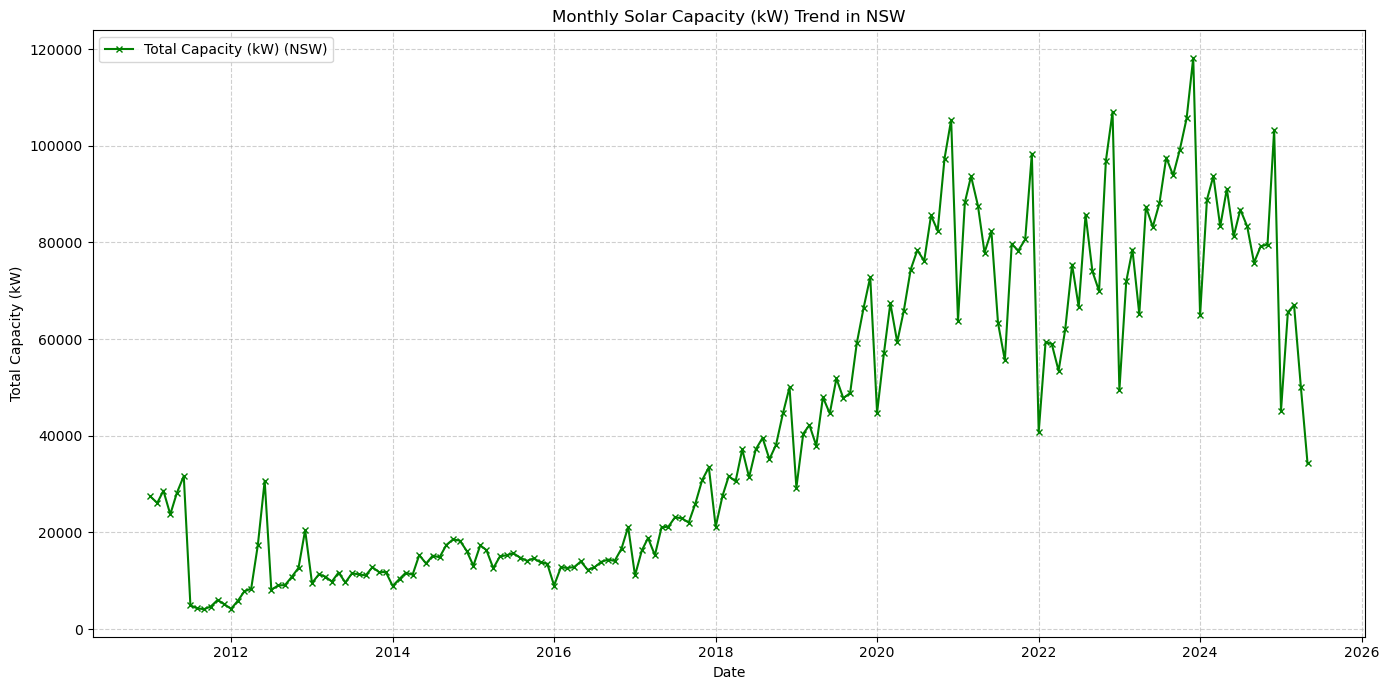

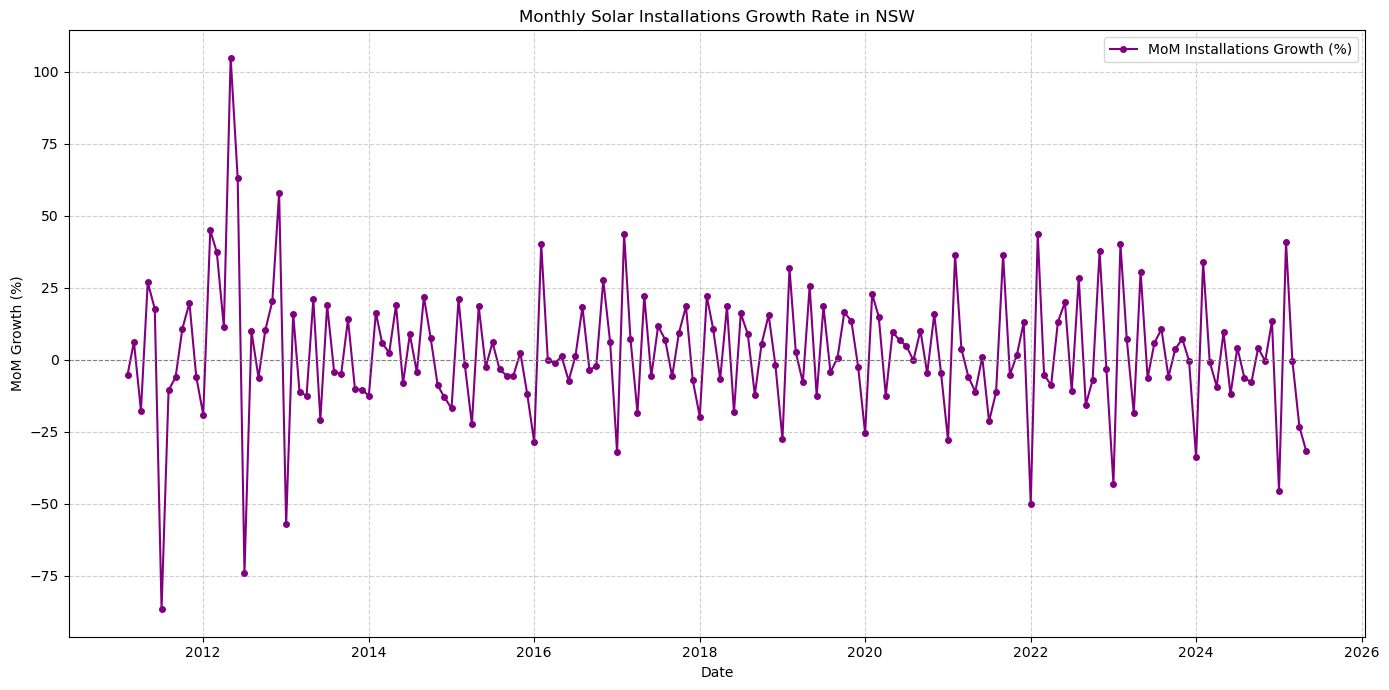

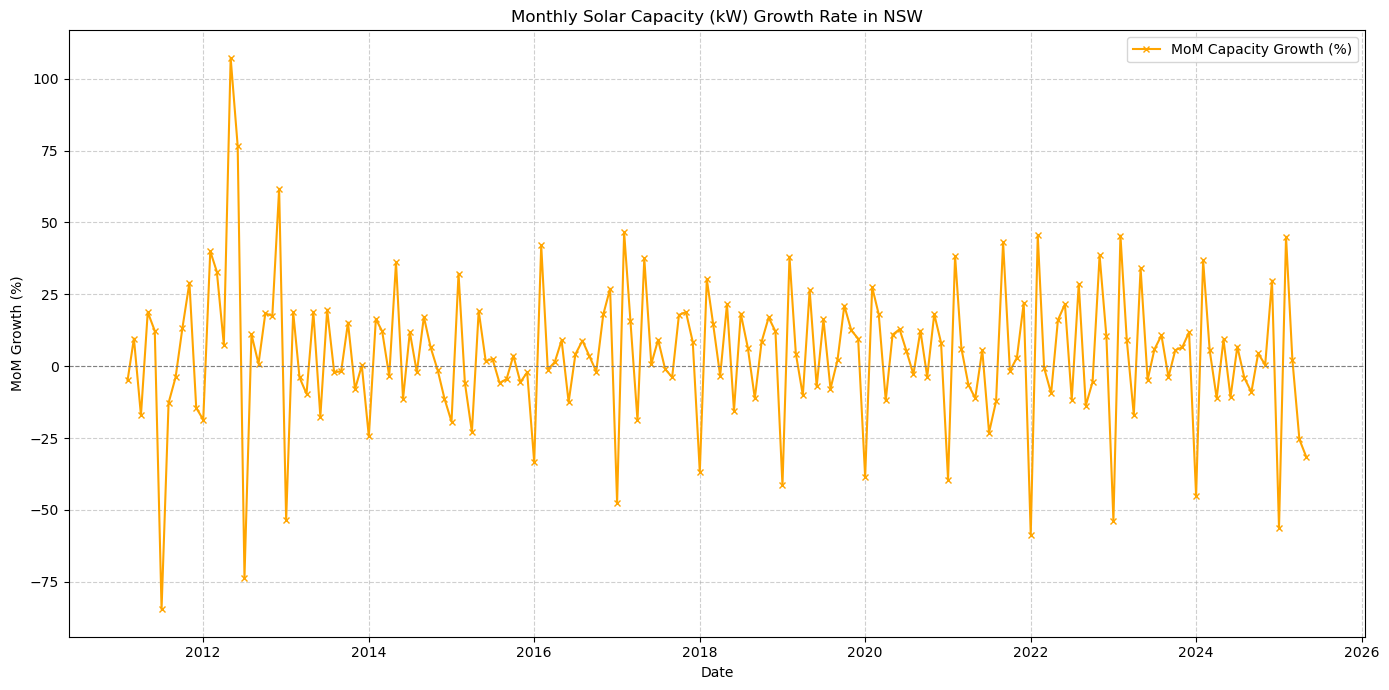


--- Top 20 Postcodes by Total Installations ---
     Postcode  Total_Num_Installations  Total_Capacity_kW  \
523      2765                    12935         119062.791   
128      2155                    12371          98830.821   
199      2259                    11571          81709.471   
401      2560                    11012          73350.242   
142      2170                    10771          89756.883   
354      2480                    10672          68022.590   
573      2830                    10525          68532.924   
325      2444                    10103          64654.889   
409      2570                    10015          83360.172   
454      2650                     9862          67942.691   
388      2540                     9699          62595.949   
331      2450                     8641          58766.313   
260      2340                     8590          63975.875   
360      2486                     8405          50617.725   
194      2250                     82

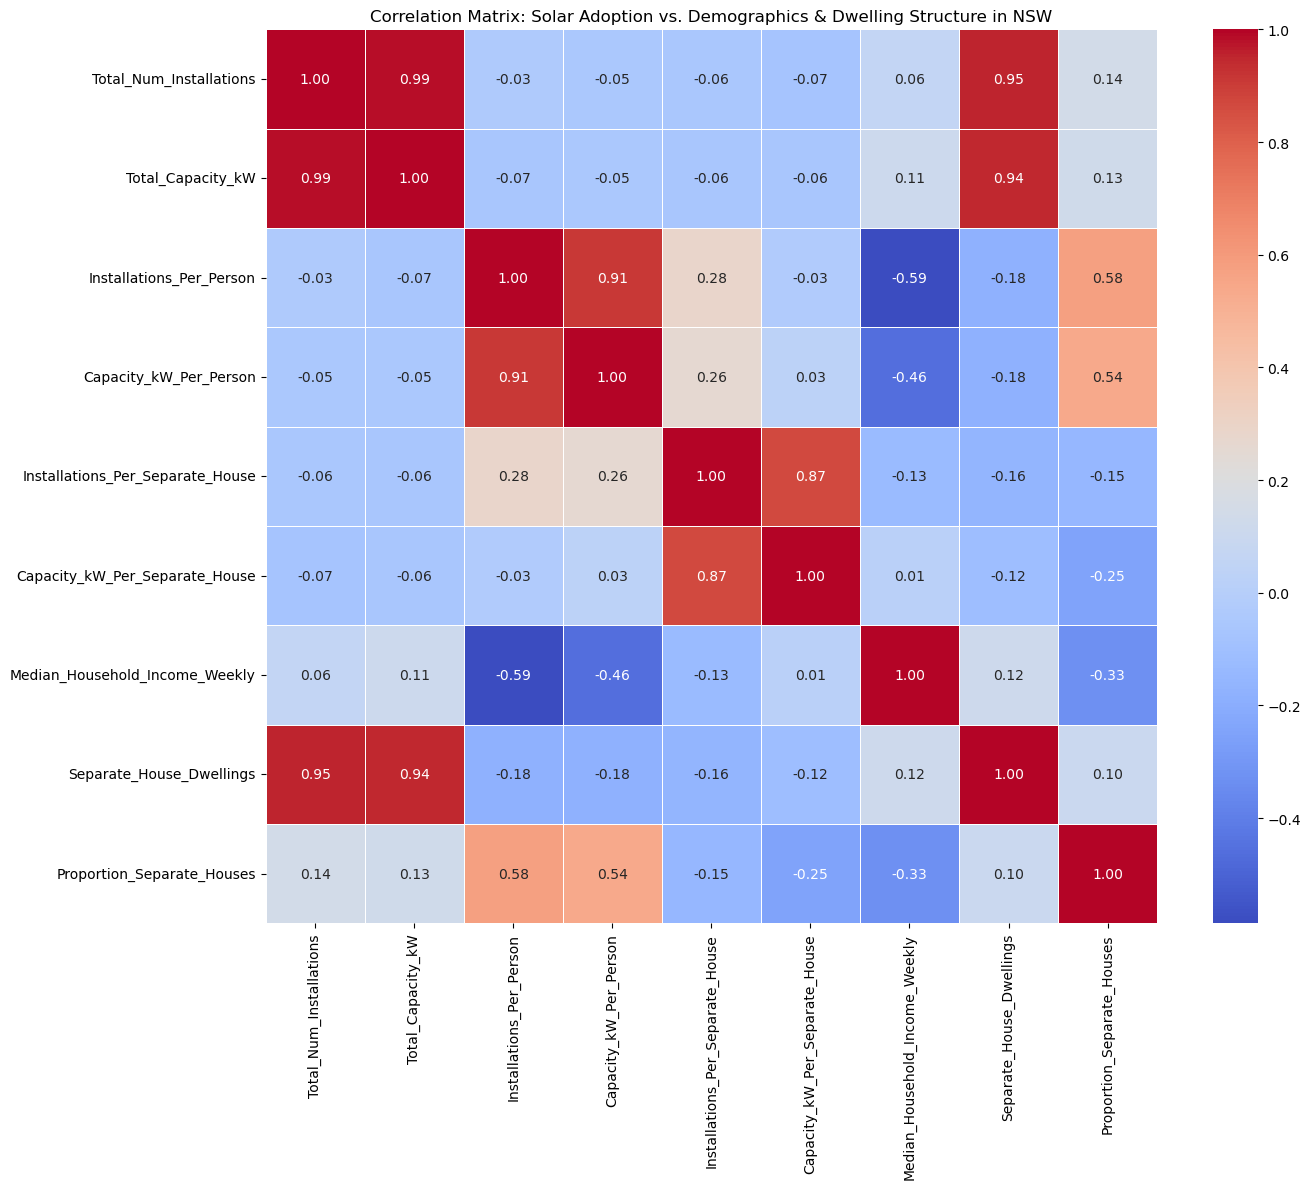


--- Visualising Normalized Relationships (Scatter Plots) ---


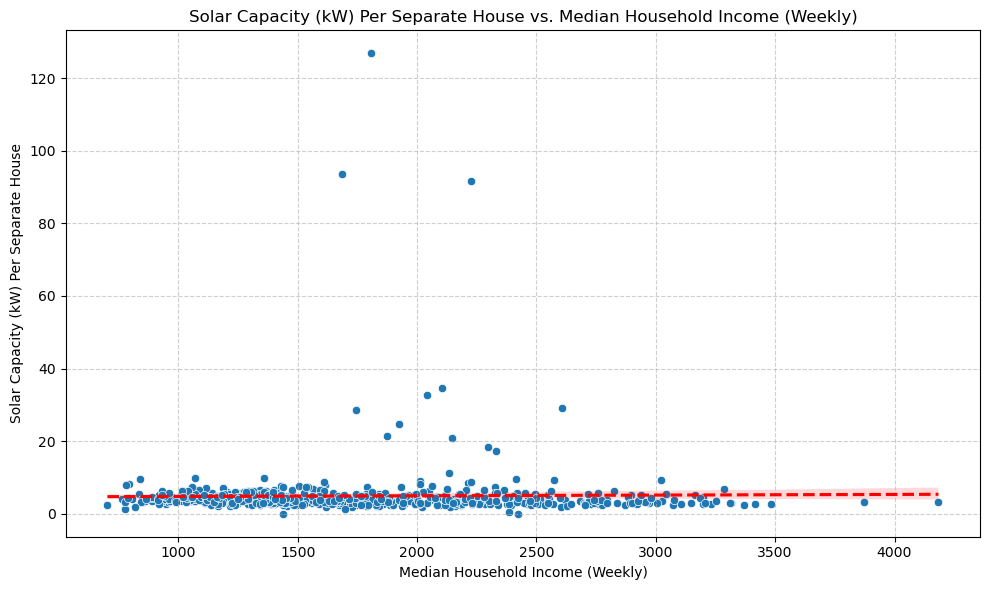

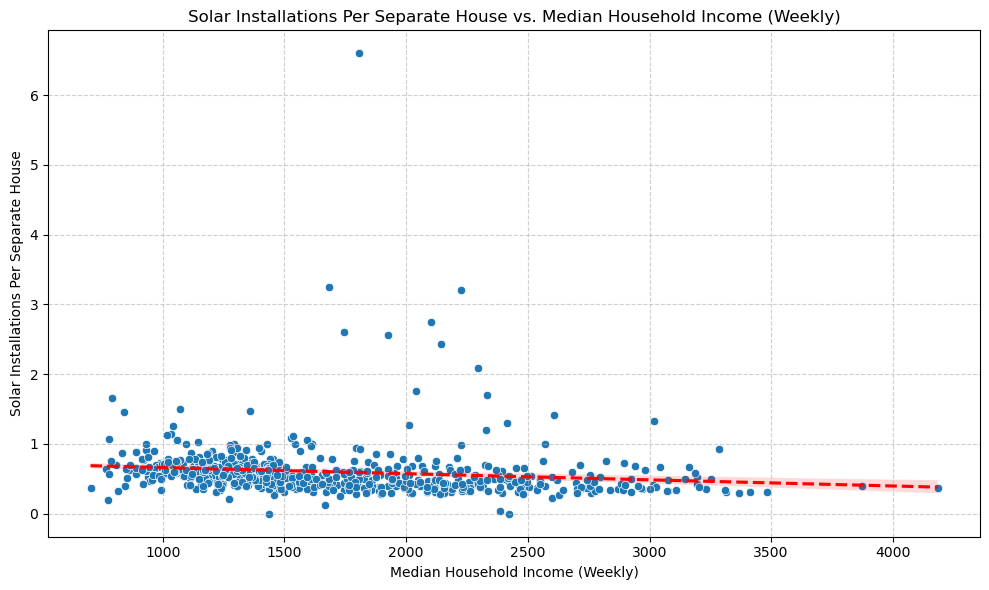

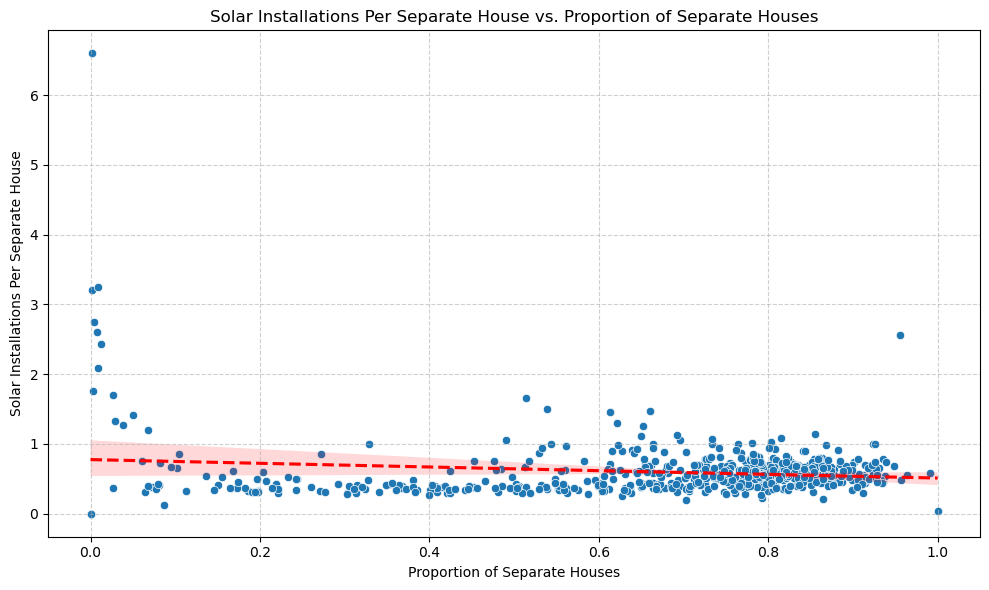


Analysis plots saved in the '/Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/' directory.
--- Step 4 Complete: Comprehensive EDA Performed ---

--- Step 5: Generating Geographic Distribution Map ---


/var/folders/0r/rzm5lkxs6r763lxm3q26yh7h0000gn/T/ipykernel_71363/3877344721.py:327: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nsw_centroid = gdf_nsw_solar_demographics.dissolve().centroid



Interactive multi-layer map saved to: /Users/yangfeng/Desktop/bootcamp/Lab 3/mini project/nsw_solar_postcode__map.html
Open this HTML file in your web browser to view the map and select different layers from the top-right corner.

--- All Requested Analysis Steps Completed ---


In [11]:
# --- Main Processing Logic ---

if __name__ == "__main__":
    print("--- Starting Solar Adoption Analysis in NSW ---")

    # --- Step 1: Load Raw Data ---
    print("\n--- Step 1: Loading Raw CER Data ---")
    try:
        df_capacity_raw = pd.read_csv(CAPACITY_FILE, skiprows=0)
        df_installations_raw = pd.read_csv(INSTALLATIONS_FILE, skiprows=0)
        print("Raw CER Data Loaded Successfully (Step 1).")
    except Exception as e:
        print(f"An error occurred during raw data loading: {e}")
        exit()
 
    df_abs_demographics = load_abs_demographics(ABS_G02_FILE, ABS_G36_FILE)
    if df_abs_demographics.empty:
        print("Fatal Error: ABS demographic data could not be loaded. Exiting analysis.")
        exit()
        
  # --- Step 2: Clean and Filter NSW CER Data ---
    print("\n--- Step 2: Cleaning and Filtering NSW CER Data ---")
    df_capacity_long = load_and_reshape_cer_data(df_capacity_raw.copy(), 'Capacity_kW')
    df_installations_long = load_and_reshape_cer_data(df_installations_raw.copy(), 'Num_Installations')
    
    df_capacity_nsw = df_capacity_long[df_capacity_long['Postcode'].apply(is_postcode_in_nsw_ranges)].copy()
    df_installations_nsw = df_installations_long[df_installations_long['Postcode'].apply(is_postcode_in_nsw_ranges)].copy()
    
    df_cer_solar_nsw = pd.merge(df_capacity_nsw, df_installations_nsw, on=['Postcode', 'Date'], how='outer')
    df_cer_solar_nsw['Capacity_kW'] = df_cer_solar_nsw['Capacity_kW'].fillna(0)
    df_cer_solar_nsw['Num_Installations'] = df_cer_solar_nsw['Num_Installations'].fillna(0)
    desired_column_order = ['Postcode', 'Date', 'Num_Installations', 'Capacity_kW']
    df_cer_solar_nsw = df_cer_solar_nsw[desired_column_order]
    print("NSW CER Solar Data Prepared.")
    
    # Aggregate CER data by postcode for merging with ABS data
    df_postcode_totals = df_cer_solar_nsw.groupby('Postcode').agg(
        Total_Num_Installations=('Num_Installations', 'sum'),
        Total_Capacity_kW=('Capacity_kW', 'sum')
    ).reset_index()
    
 # --- Step 3: Integrate ABS Data and Calculate All Metrics ---
    print("\n--- Step 3: Integrating ABS Data and Calculating All Metrics ---")
    df_solar_demographics = pd.merge(
        df_postcode_totals,
        df_abs_demographics,
        on='Postcode',
        how='inner' 
    )

    # Drop rows where Total_Persons_in_Dwellings or Total_Dwellings is 0 to avoid division by zero.
    df_solar_demographics = df_solar_demographics[
        (df_solar_demographics['Total_Persons_in_Dwellings'] > 0) &
        (df_solar_demographics['Total_Dwellings'] > 0)
    ].copy()
    
    # Calculate Normalised Metrics
    df_solar_demographics['Installations_Per_Person'] = (
        df_solar_demographics['Total_Num_Installations'] / df_solar_demographics['Total_Persons_in_Dwellings']
    )
    df_solar_demographics['Capacity_kW_Per_Person'] = (
        df_solar_demographics['Total_Capacity_kW'] / df_solar_demographics['Total_Persons_in_Dwellings']
    )
    df_solar_demographics['Proportion_Separate_Houses'] = (
        df_solar_demographics['Separate_House_Dwellings'] / df_solar_demographics['Total_Dwellings']
    )
    df_solar_demographics['Proportion_Separate_Houses'] = df_solar_demographics['Proportion_Separate_Houses'].fillna(0)

    # Calculate Installations per Separate House (handle division by zero)
    df_solar_demographics['Installations_Per_Separate_House'] = df_solar_demographics.apply(
        lambda row: row['Total_Num_Installations'] / row['Separate_House_Dwellings']
        if row['Separate_House_Dwellings'] > 0 else 0, axis=1
    )

    # Calculate Capacity per Separate House (handle division by zero)
    df_solar_demographics['Capacity_kW_Per_Separate_House'] = df_solar_demographics.apply(
        lambda row: row['Total_Capacity_kW'] / row['Separate_House_Dwellings']
        if row['Separate_House_Dwellings'] > 0 else 0, axis=1
    )
    print("\nMerged Solar and ABS Demographic Data with All Normalised Metrics (Head):")
    print(df_solar_demographics[[
        'Postcode',
        'Total_Persons_in_Dwellings',
        'Median_Household_Income_Weekly',
        'Separate_House_Dwellings',
        'Proportion_Separate_Houses',
        'Installations_Per_Person',
        'Capacity_kW_Per_Person',
        'Installations_Per_Separate_House', 
        'Capacity_kW_Per_Separate_House' 
    ]].head())
    print(f"Merged data shape: {df_solar_demographics.shape}")


    # --- Step 4: Perform Comprehensive EDA and Plot Trends ---
    print("\n--- Step 4: Performing Comprehensive EDA and Plotting Trends ---")

    # Overall NSW Solar Trends & Growth Rates
    df_nsw_total_monthly = df_cer_solar_nsw.groupby('Date').agg(
        Total_Installations=('Num_Installations', 'sum'),
        Total_Capacity_kW=('Capacity_kW', 'sum')
    ).reset_index().sort_values(by='Date')

    df_nsw_total_monthly['MoM_Installations_Growth'] = df_nsw_total_monthly['Total_Installations'].pct_change() * 100
    df_nsw_total_monthly['MoM_Capacity_Growth'] = df_nsw_total_monthly['Total_Capacity_kW'].pct_change() * 100
    
    # PLOT 1: Total Installations Trend
    plt.figure(figsize=(14, 7))
    plt.plot(df_nsw_total_monthly['Date'], df_nsw_total_monthly['Total_Installations'], label='Total Installations (NSW)', marker='o', markersize=4, color='blue')
    plt.title('Monthly Solar Installations Trend in NSW')
    plt.xlabel('Date')
    plt.ylabel('Total Installations')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'nsw_solar_installations_trend.png')) 
    plt.show()

    # PLOT 2: Total Capacity (kW) Trend
    plt.figure(figsize=(14, 7))
    plt.plot(df_nsw_total_monthly['Date'], df_nsw_total_monthly['Total_Capacity_kW'], label='Total Capacity (kW) (NSW)', marker='x', markersize=4, color='green')
    plt.title('Monthly Solar Capacity (kW) Trend in NSW') # New title
    plt.xlabel('Date')
    plt.ylabel('Total Capacity (kW)') # New y-label
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'nsw_solar_capacity_trend.png')) 
    plt.show()

    # PLOT 3: Monthly Installations Growth Rate 
    plt.figure(figsize=(14, 7))
    plt.plot(df_nsw_total_monthly['Date'], df_nsw_total_monthly['MoM_Installations_Growth'], label='MoM Installations Growth (%)', marker='o', markersize=4, color='purple')
    plt.title('Monthly Solar Installations Growth Rate in NSW')
    plt.xlabel('Date')
    plt.ylabel('MoM Growth (%)')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'nsw_solar_installations_mom_growth.png'))
    plt.show()

    # PLOT 4: Monthly Capacity Growth Rate 
    plt.figure(figsize=(14, 7))
    plt.plot(df_nsw_total_monthly['Date'], df_nsw_total_monthly['MoM_Capacity_Growth'], label='MoM Capacity Growth (%)', marker='x', markersize=4, color='orange')
    plt.title('Monthly Solar Capacity (kW) Growth Rate in NSW')
    plt.xlabel('Date')
    plt.ylabel('MoM Growth (%)')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'nsw_solar_capacity_mom_growth.png'))
    plt.show()

    # --- Identifying Top Areas (Postcodes) ---
    print("\n--- Top 20 Postcodes by Total Installations ---")
    print(df_solar_demographics.sort_values(by='Total_Num_Installations', ascending=False).head(20)[
        ['Postcode', 'Total_Num_Installations', 'Total_Capacity_kW', 'Median_Household_Income_Weekly', 'Separate_House_Dwellings', 'Installations_Per_Separate_House']
    ])

    print("\n--- Top 20 Postcodes by Total Capacity (kW) ---")
    print(df_solar_demographics.sort_values(by='Total_Capacity_kW', ascending=False).head(20)[
        ['Postcode', 'Total_Num_Installations', 'Total_Capacity_kW', 'Median_Household_Income_Weekly', 'Separate_House_Dwellings', 'Capacity_kW_Per_Separate_House']
    ])

    print("\n--- Top 20 Postcodes by Installations Per Person ---")
    print(df_solar_demographics.sort_values(by='Installations_Per_Person', ascending=False).head(20)[
        ['Postcode', 'Installations_Per_Person', 'Total_Num_Installations', 'Total_Persons_in_Dwellings', 'Median_Household_Income_Weekly']
    ])

    print("\n--- Top 20 Postcodes by Capacity (kW) Per Person ---")
    print(df_solar_demographics.sort_values(by='Capacity_kW_Per_Person', ascending=False).head(20)[
        ['Postcode', 'Capacity_kW_Per_Person', 'Total_Capacity_kW', 'Total_Persons_in_Dwellings', 'Median_Household_Income_Weekly']
    ])

    print("\n--- Top 20 Postcodes by Installations Per Separate House ---")
    print(df_solar_demographics.sort_values(by='Installations_Per_Separate_House', ascending=False).head(20)[
        ['Postcode', 'Installations_Per_Separate_House', 'Total_Num_Installations', 'Separate_House_Dwellings', 'Proportion_Separate_Houses', 'Median_Household_Income_Weekly']
    ])

    print("\n--- Top 20 Postcodes by Capacity (kW) Per Separate House ---")
    print(df_solar_demographics.sort_values(by='Capacity_kW_Per_Separate_House', ascending=False).head(20)[
        ['Postcode', 'Capacity_kW_Per_Separate_House', 'Total_Capacity_kW', 'Separate_House_Dwellings', 'Proportion_Separate_Houses', 'Median_Household_Income_Weekly']
    ])
    print("Top Areas Identified (Step 4 complete).")

    # --- Correlation Analysis ---
    print("\n--- Correlation Analysis (Updated Metrics) ---")
    correlation_matrix = df_solar_demographics[[
        'Total_Num_Installations',
        'Total_Capacity_kW',
        'Installations_Per_Person',
        'Capacity_kW_Per_Person',
        'Installations_Per_Separate_House',
        'Capacity_kW_Per_Separate_House',
        'Median_Household_Income_Weekly',
        'Separate_House_Dwellings', 
        'Proportion_Separate_Houses' 
    ]].corr()

    print("Correlation Matrix:")
    print(correlation_matrix)

    plt.figure(figsize=(14, 12)) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix: Solar Adoption vs. Demographics & Dwelling Structure in NSW')
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'correlation_matrix_updated.png'))
    plt.show()

    # --- Scatter Plots for Normalised Relationships ---
    print("\n--- Visualising Normalised Relationships (Scatter Plots) ---")

    # Scatter plot: Capacity per Separate House vs. Median Household Income
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_solar_demographics,
        x='Median_Household_Income_Weekly',
        y='Capacity_kW_Per_Separate_House'
    )
    sns.regplot(
        data=df_solar_demographics,
        x='Median_Household_Income_Weekly',
        y='Capacity_kW_Per_Separate_House',
        scatter=False,
        color='red',
        line_kws={'linestyle':'--'}
    )
    plt.title('Solar Capacity (kW) Per Separate House vs. Median Household Income (Weekly)')
    plt.xlabel('Median Household Income (Weekly)')
    plt.ylabel('Solar Capacity (kW) Per Separate House')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'scatter_capacity_per_separate_house_vs_income.png'))
    plt.show()

    # Scatter plot: Installations per Separate House vs. Median Household Income
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_solar_demographics,
        x='Median_Household_Income_Weekly',
        y='Installations_Per_Separate_House'
    )
    sns.regplot(
        data=df_solar_demographics,
        x='Median_Household_Income_Weekly',
        y='Installations_Per_Separate_House',
        scatter=False,
        color='red',
        line_kws={'linestyle':'--'}
    )
    plt.title('Solar Installations Per Separate House vs. Median Household Income (Weekly)')
    plt.xlabel('Median Household Income (Weekly)')
    plt.ylabel('Solar Installations Per Separate House')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'scatter_installations_per_separate_house_vs_income.png'))
    plt.show()

    # Scatter plot: Installations per Separate House vs. Proportion of Separate Houses 
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_solar_demographics,
        x='Proportion_Separate_Houses',
        y='Installations_Per_Separate_House' 
    )
    sns.regplot(
        data=df_solar_demographics,
        x='Proportion_Separate_Houses',
        y='Installations_Per_Separate_House', 
        scatter=False,
        color='red',
        line_kws={'linestyle':'--'}
    )
    plt.title('Solar Installations Per Separate House vs. Proportion of Separate Houses') 
    plt.xlabel('Proportion of Separate Houses')
    plt.ylabel('Solar Installations Per Separate House') 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(data_dir, 'scatter_installations_per_separate_house_vs_proportion_separate_houses.png')) 
    plt.show()

    print(f"\nAnalysis plots saved in the '{data_dir}' directory.")
    print("--- Step 4 Complete: Comprehensive EDA Performed ---")

 # --- Step 5: Geographic Distribution on Map ---
    print("\n--- Step 5: Generating Geographic Distribution Map ---")

    try:
        # Merge geographic data with solar and demographic data
        gdf_poa = gpd.read_file(poa_file)
        
        geo_postcode_col = None
        for col in ['POA_CODE21', 'POA_CODE_2016', 'POA_NAME', 'POA_CODE', 'poa_code']:
            if col in gdf_poa.columns:
                geo_postcode_col = col
                break
        
        if geo_postcode_col is None:
            raise ValueError(f"Could not find a postcode column in the geographic data. Looked for common names. Found: {gdf_poa.columns.tolist()}")

        gdf_poa['Postcode'] = pd.to_numeric(gdf_poa[geo_postcode_col].str.replace('POA', ''), errors='coerce')
        gdf_poa = gdf_poa.dropna(subset=['Postcode'])
        gdf_poa['Postcode'] = gdf_poa['Postcode'].astype(int)

        nsw_geo_mask = gdf_poa['Postcode'].apply(is_postcode_in_nsw_ranges)
        gdf_nsw = gdf_poa[nsw_geo_mask].copy()
        
        # Merge with the comprehensive df_solar_demographics
        gdf_nsw_solar_demographics = gdf_nsw.merge(df_solar_demographics, on='Postcode', how='left')

        # Fill NaN values for postcodes that have no solar/demographic data
        for col in df_solar_demographics.columns:
            if col != 'Postcode': # Don't fill Postcode NaNs if any, though inner join should prevent this
                if gdf_nsw_solar_demographics[col].dtype in ['int64', 'float64']:
                    gdf_nsw_solar_demographics[col] = gdf_nsw_solar_demographics[col].fillna(0)
                else:
                    gdf_nsw_solar_demographics[col] = gdf_nsw_solar_demographics[col].fillna('N/A') 

        # Format Proportion_Separate_Houses as percentage 
        gdf_nsw_solar_demographics['Proportion_Separate_Houses_PCT'] = (
            gdf_nsw_solar_demographics['Proportion_Separate_Houses'] * 100
        ).round(2).astype(str) + '%'
        
        nsw_centroid = gdf_nsw_solar_demographics.dissolve().centroid
        map_center = [nsw_centroid.y.iloc[0], nsw_centroid.x.iloc[0]]

        m = folium.Map(location=map_center, zoom_start=7, control_scale=True)

        # Define fields and aliases for Tooltip (hover) and Popup (click)
        display_fields = [
            'Postcode',
            'Total_Num_Installations',
            'Total_Capacity_kW',
            'Median_Household_Income_Weekly', 
            'Total_Persons_in_Dwellings', 
            'Separate_House_Dwellings', 
            'Proportion_Separate_Houses_PCT',
            'Installations_Per_Person',
            'Capacity_kW_Per_Person',
            'Installations_Per_Separate_House', 
            'Capacity_kW_Per_Separate_House' 
        ]
        display_aliases = [
            'Postcode:',
            'Total Installations:',
            'Total Capacity (kW):',
            'Median Household Income (Weekly):',
            'Total Population:',
            'Separate Houses:',
            'Prop. Houses:',
            'Installs/Person:',
            'kW/Person:',
            'Installs/House:', 
            'kW/House:' 
        ]

        # Define metrics for layering and their colormaps/styles (NEW MULTIPLE LAYERS)
        map_metrics = {
            'Total Installations': {
                'column': 'Total_Num_Installations',
                'colors': ['#ffffcc', '#800026'],
                'caption': 'Total Solar Installations'
            },
            'Total Capacity (kW)': {
                'column': 'Total_Capacity_kW',
                'colors': ['#edf8fb', '#006d2c'],
                'caption': 'Total Solar Capacity (kW)'
            },
            'Installations/Person': {
                'column': 'Installations_Per_Person',
                'colors': ['#f7fcfd', '#4d004b'],
                'caption': 'Installations per Person'
            },
            'Capacity (kW)/Person': {
                'column': 'Capacity_kW_Per_Person',
                'colors': ['#f0f9e8', '#016c59'],
                'caption': 'Capacity (kW) per Person'
            }
        }
        # Set the default visible layer
        default_visible_layer_name = 'Total Installations'
        # Add a colormap to the map for Total Capacity (kW) by default
        # Create colormaps dynamically and add GeoJson layers for each metric
        for name, details in map_metrics.items():
            metric_column = details['column']
            colors = details['colors']
            caption = details['caption']

            # Calculate vmin, vmax for each metric, handling potential all-zero data
            metric_min = gdf_nsw_solar_demographics[metric_column].min()
            metric_max = gdf_nsw_solar_demographics[metric_column].max()
            
            # Ensure vmin and vmax are not identical (e.g., if all values are 0)
            # Add a small epsilon if min == max and max is not zero, or set vmin/vmax to 0/1 if all are zero.
            if metric_min == metric_max:
                if metric_max == 0:
                    vmin = 0
                    vmax = 1 # Small range for visual distinction if all zero, or can just be 0 if desired
                else:
                    vmin = metric_min * 0.9 # Slightly below if non-zero constant
                    vmax = metric_max * 1.1 # Slightly above
            else:
                vmin = metric_min
                vmax = metric_max

            colormap = cm.LinearColormap(colors=colors, vmin=vmin, vmax=vmax, caption=caption)
            m.add_child(colormap) # Add colormap legend to the map

            # Define a style function for the current metric
            def style_function_generator(column, cmap):
                def style_function(feature):
                    value = feature['properties'][column]
                    return {
                        'fillColor': cmap(value) if value is not None else '#FFFFFF',
                        'color': 'black',
                        'weight': 0.5,
                        'fillOpacity': 0.6
                    }
                return style_function

            # Create a GeoJson layer for the current metric
            folium.GeoJson(
                gdf_nsw_solar_demographics.__geo_interface__,
                name=name, # Name for the layer control
                style_function=style_function_generator(metric_column, colormap),
                tooltip=GeoJsonTooltip(fields=display_fields, aliases=display_aliases, localize=True, sticky=True),
                popup=GeoJsonPopup(fields=display_fields, aliases=display_aliases, localize=True, max_width=400),
                highlight_function=lambda x: {'fillColor': '#d3d3d3', 'color': '#ff0000', 'weight': 3, 'fillOpacity': 0.7},
                show=(name == default_visible_layer_name)
            ).add_to(m)

        folium.LayerControl().add_to(m) # Add layer control to the map

        map_output_path = os.path.join(data_dir, 'nsw_solar_postcode__map.html') 
        m.save(map_output_path)
        print(f"\nInteractive multi-layer map saved to: {map_output_path}")
        print("Open this HTML file in your web browser to view the map and select different layers from the top-right corner.")

    except FileNotFoundError as e:
        print(f"Error: Geographic data file not found. Please check path: {e.filename}")
        print("Ensure 'POA_2021_AUST_GDA2020.shp' is correctly located within 'POA_2021_AUST_GDA2020_SHP' folder inside your project directory.")
    except Exception as e:
        print(f"An error occurred during map generation: {e}")
        print(f"Error details: {e}")

    print("\n--- All Requested Analysis Steps Completed ---")